In [13]:
import numpy
import scipy
from os.path import join
import matplotlib.pyplot as plt
import texplot
import matplotlib.ticker as mticker

# Imports from freealg
import freealg
from freealg import AlgebraicForm
from freealg.visualization import plot_flow, plot_mass, ridgeplot
from freealg.visualization._api_plot_util import _decimal_text, _k_pow2_formatter
from freealg import supp

# Plotting options
plot_dir = './plots'
save_filename = 'Umatrix64k'
latex = True

# Diffusion Model

Data's ESD replicates Fig 4 (right panel) of:

* [Why Diffusion Models Don’t Memorize: The Role of Implicit Dynamical Regularization in Training](https://openreview.net/pdf?id=BSZqpqgqM0)

The data is the matrix $\mathbf{U}$ in the above paper, here generated at the size $64K \times 64K$.

The input file loaded below (`Umatrix64k_eigs.npz`) contains a list of numpy arrays. Each array is the eigenvalues of a sumbatrix, ranging from the size $1K, 2K, 4K, \dots, 64K$.

Idx   Size
---  -----
0     1000
1     2000
2     4000
3     8000
4    16000
5    32000
6    64000



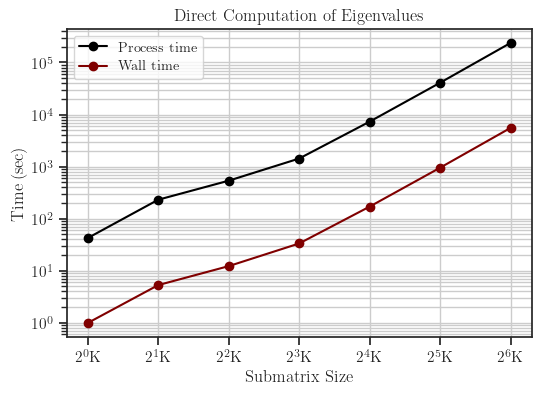

In [2]:
# Load input file
filename = 'Umatrix64k_eigs.npz'
dir_ = '/home/sia/work/scripts/free/Xperimental/hessian'
data = numpy.load(join(dir_, filename), allow_pickle=True)
out = data['out'].item()

# Extract variables
sizes = out['sizes']                 # List of sizes of the submatrices
eigs = out['eigs']                   # List of eigenvalues per each submatrix
wall_times = out['wall_times']       # List of wall times taken to compute eigenvalues
proc_times = out['proc_times']       # List of CPU process times taken to compute eigenvalues
n, p = out['shape']                  # Dimension of the original matrix (largest matrix)

# Sizes of submatrices
print('Idx   Size')
print('---  -----')
for i in range(sizes.size):
    print(f'{i:<2d}  {sizes[i]:>6d}')
print('')

# Plot wall and process times
with texplot.theme(use_latex=latex):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(sizes, proc_times, '-o', color='black', label='Process time')
    ax.plot(sizes, wall_times, '-o', color='maroon', label='Wall time')
    ax.set_xlabel('Submatrix Size')
    ax.set_ylabel('Time (sec)')
    ax.set_title('Direct Computation of Eigenvalues')
    ax.legend(fontsize='small')
    ax.set_xscale('log', base=2)
    ax.xaxis.set_major_locator(mticker.LogLocator(base=2, subs=(1000/512.0,)))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(_k_pow2_formatter))
    ax.set_yscale('log')
    ax.grid(True, which='both')
    plt.show()

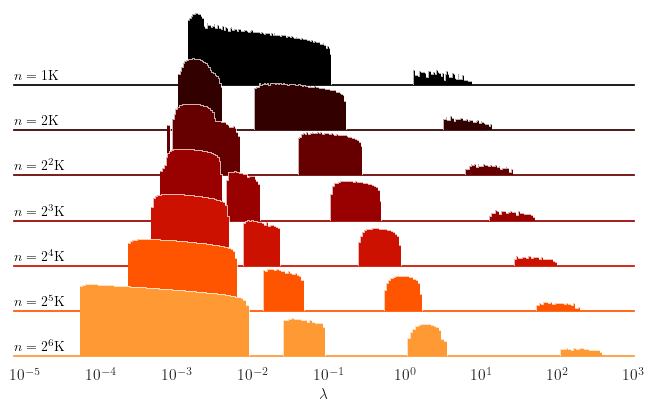

In [3]:
ridgeplot(sizes, eigs=eigs, log=True, scaley=False, hspace=-0.4,
          text_side='left', xlim=(7e-6, 1e3), figsize=(8, 4.5),
          label_mode='pow-int', latex=latex, save=False, nbins=200)

# Fit Spectral Curve

In [4]:
# Index to choose the initial sub-matrix size
start_idx = 2

# Detect support from histogram
support = supp(eigs[start_idx], method='hist', tol=0, nbins=150, log=True)
print('\n------------------------------------------')
print('Support (detected from histogram):')
for i, supp in enumerate(support):
    print(f'\tInterval {i+1}: ({supp[0]:>9.4f}, {supp[1]:>9.4f})')

# Smaller delta lowers the density baseline curve 1/x^2.
af = AlgebraicForm(eigs[start_idx],
                   # support=support,
                   support=None,
                   delta=1e-8, log=True)

# We use deg_z = 1 since we guess the data is closely related to free Levy
# model, where deg_z is always 1. We also set _deg_m = 5 to have the capacity
# of representing 4 bulks once decompressed.
print('\n------------------------------------------')
deg_m = 5
deg_z = 1

coeffs = af.fit(
    deg_m, deg_z, reg=0,
    # r=[1.25, 6, 10],
    # n_r=[3, 2, 1],
    # n_samples=4096,
    # y_eps=1e-3,
    # x_pad=0.0,
    normalize=True, triangular=None,
    mu='auto', mu_reg=0, verbose=True)

print('\n------------------------------------------')
print('Support (estimated from polynomial):')
est_supp = af.support()
for i, supp in enumerate(est_supp):
    print(f'\tInterval {i+1}: ({supp[0]:>9.4f}, {supp[1]:>9.4f})')

print('\n------------------------------------------')
print('Atoms (estimated from polynomial):')
for i, atom in enumerate(af.atoms()):
    print(f'\tAtom {i+1}. x: {atom[0]:>4.1e}, weight: {100.0*atom[1]:>4.1f}%')


------------------------------------------
Support (detected from histogram):
	Interval 1: (   0.0007,    0.0064)
	Interval 2: (   0.0377,    0.2727)
	Interval 3: (   6.1221,   27.0271)

------------------------------------------
fit residual max  : 2.5865e+00
fit residual 99.9%: 1.9150e+00

Coefficients (real)
+0.99999173 +14.16717148 +1.45789166 +0.00116185 -0.00000916 +0.00000000 
+0.00000000 +1.00006738 +14.60136517 +1.84358664 +0.00577178 +0.00000075 

Coefficients (imag) norm: 0.0000e+00

	frac_bad: 1.000
	n_bad   : 128
	n_test  : 128

------------------------------------------
Support (estimated from polynomial):
	Interval 1: (   0.0035,    0.0054)
	Interval 2: (   0.0427,    0.2445)
	Interval 3: (  10.0332,   19.7772)

------------------------------------------
Atoms (estimated from polynomial):
	Atom 1. x: -4.5e-04, weight:  0.0%


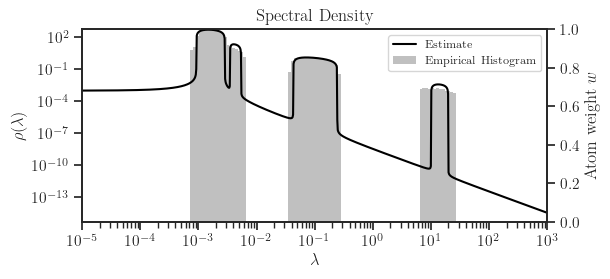


Mass: 1.00005887


In [5]:
# Check the fitted density (at start size)
x_min = 1e-5
x_max = 1e3
x = numpy.geomspace(x_min, x_max, 1000)
rho0 = af.density(x, plot=True, latex=latex)

# Check mass (at start size)
print('')
mass = numpy.trapz(rho0, x)
print(f'Mass: {mass:0.8f}')

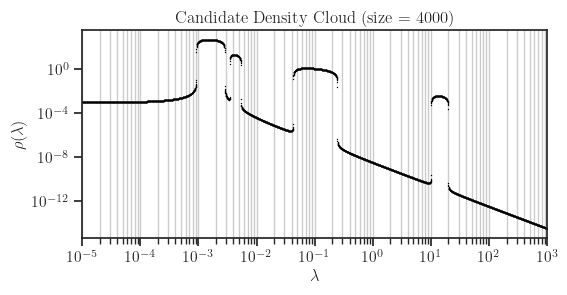

In [6]:
# Check if the density plotted above is formed by correct roots. For this,
# we plot all possible roots below.
x_highres = numpy.geomspace(x_min, x_max, 5000)
af.candidates(size=sizes[start_idx], x=x_highres, delta=1e-8,
              markersize=1, latex=latex)

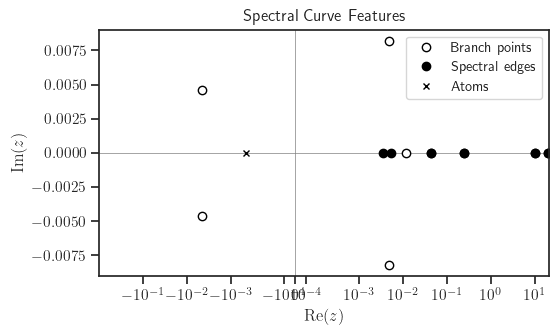


i   Branch Points        Spectral Edge
--  -------------------  -------------
1   +19.7772+0.000e+00i  Maybe
2   +10.0332+0.000e+00i  Maybe
3    +0.2445+0.000e+00i  Maybe
4    +0.0426+0.000e+00i  Maybe
5    +0.0119+0.000e+00i  Maybe
6    +0.0048+8.201e-03i  No
7    +0.0048-8.201e-03i  No
8    -0.0046+4.590e-03i  No
9    -0.0046-4.590e-03i  No


In [7]:
# Branch points
bp = af.branch_points(tol=1e-16, real_tol=1e-16, plot=True, latex=latex)

# A branch point on real axis is a candidate to also be a spectral edge.
# Those with near zero imaginary part are flagged as maybe a spectral edge.
print('\ni   Branch Points        Spectral Edge')
print('--  -------------------  -------------')
for i in range(bp.size):
    print(f'{i+1}   {bp[i].real:>+8.4f}{bp[i].imag:>+5.3e}i', end='  ')
    if numpy.abs(bp[i].imag) < 1e-14:
        print('Maybe')
    else:
        print('No')

# Free Decompression

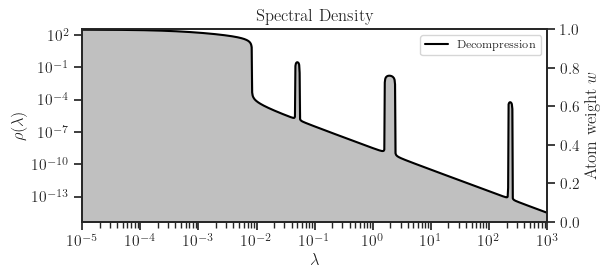

In [8]:
# Choosing the largest sub-matrix size to decompress to
end_idx = sizes.size - 1

# Subset of sizes to apply free decompression
fd_sizes = sizes[start_idx:end_idx+1]

# x span of decompression
x_min = 1e-5
x_max = 1e3
x = numpy.geomspace(x_min, x_max, 1000)

# This is needed to ensure roots do not jump between sheets
newton_opt = dict(
    dt_max=0.02,
)

# Using method of characteristics (MoC) with 2x2 Newton and
# predictor/corrector (PC) to stabilize and speedup convergence
rho, x, atoms = af.decompress(
    fd_sizes, x=x, method='moc', min_n_times=100,
    newton_opt=newton_opt, return_atoms=True, atom_eps=None,
    verbose=False, plot=True, latex=latex)

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/Umatrix64k-flow.pdf".


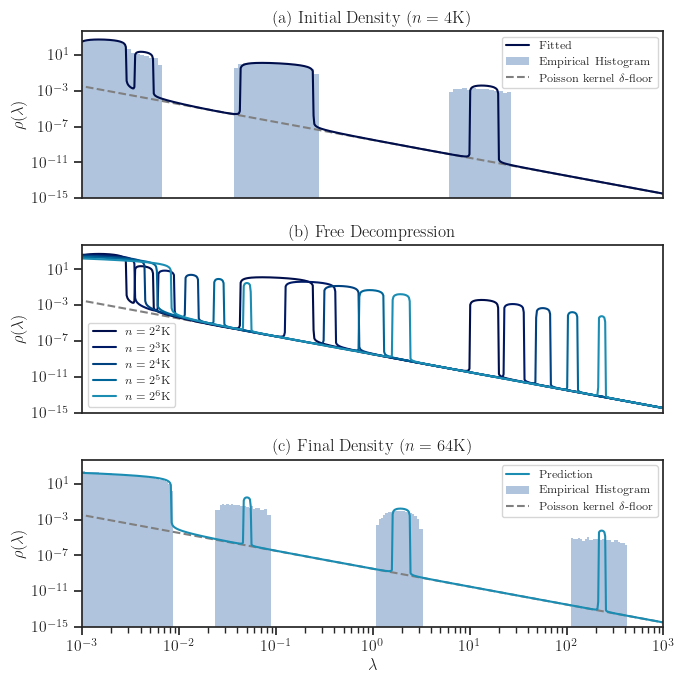

In [14]:
plot_flow(fd_sizes, x, rho, eigs[start_idx], eigs[end_idx], delta=af.delta,
          xlim=(1e-3, 1e3),
          ylim=(1e-15, 5e3),
          nbins=(100, 300),
          share_ax=True,
          layout='vertical',
          title='Free Decompression',
          cmap=plt.cm.ocean,
          c_range=(0.3, 0.7),
          hist_color='lightsteelblue',
          label_mode='pow-int',
          log=True,
          latex=latex,
          save=join(plot_dir, save_filename + '-flow.pdf'))

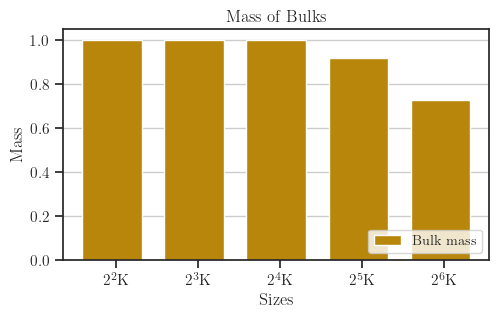

In [11]:
plot_mass(fd_sizes, x, rho, atoms=None, log_x=True, gap=0.7, latex=latex,
          save=False)